Here I'll try to understand the architecture of U-Net with the dataset Oxford-IIIT Pet Dataset

In [1]:
import torch
from torch.utils.data import Dataset
from torchvision.datasets import OxfordIIITPet
import torchvision.transforms.functional as TF
from PIL import Image
import numpy as np

class PetSegmentationDataset(Dataset):
    def __init__(self, root="./data", split="trainval", img_size=256):
        # download=True only needed once
        self.base = OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=True,
        )
        self.img_size = img_size

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, mask = self.base[idx]  # both are PIL Images

        # Resize image (bilinear is fine for images)
        image = TF.resize(image, [self.img_size, self.img_size])
        # Resize mask with NEAREST — never interpolate class labels
        mask = TF.resize(mask, [self.img_size, self.img_size],
                          interpolation=TF.InterpolationMode.NEAREST)

        # image -> tensor, normalized to [0,1] then standardized
        image = TF.to_tensor(image)  # (3, H, W), float in [0,1]
        image = TF.normalize(image, mean=[0.4783, 0.4459, 0.3957],
                             std=[0.2261, 0.2230, 0.2247])

        # mask -> raw trimap values are {1,2,3}: pet, background, boundary
        mask = np.array(mask, dtype=np.int64)
        mask = mask - 1  # remap to {0,1,2}: 0=pet, 1=background, 2=boundary
        mask = torch.from_numpy(mask)  # (H, W), dtype long

        return image, mask

First, we’ll check whether our RGB channels are normalized.

In [2]:
ds_raw = PetSegmentationDataset()
loader = torch.utils.data.DataLoader(ds_raw, batch_size=64, shuffle=False)

mean = 0.0
std = 0.0
n = 0
for images, _ in loader:
    b = images.size(0)
    images = images.view(b, images.size(1), -1)  # (B, 3, H*W)
    mean += images.mean(2).sum(0)   # sum of per-image-per-channel means
    std += images.std(2).sum(0)
    n += b
mean /= n
std /= n
print(mean, std)

tensor([-6.8854e-05, -1.7329e-04, -3.4413e-05]) tensor([1.0001, 1.0001, 0.9999])


I wrote the class below myself.

In [3]:
class PetSegmentationDataset(Dataset):
    def __init__(self, root = './data', split = 'trainval', img_size = 256):
        
        self.img_size = img_size
        self.base = OxfordIIITPet(
            root = root,
            split= split,
            target_types="segmentation",
            download= True
        )
    
    def __len__(self):
        return len(self.base)

    def __getitem__(self, index):
        img, mask = self.base[index]

        img = TF.resize(img, [self.img_size, self.img_size])
        mask = TF.resize(mask, [self.img_size, self.img_size],
                         interpolation= TF.InterpolationMode.NEAREST)

        img = TF.to_tensor(img)
        img = TF.normalize(img,
            mean=[0.4783, 0.4459, 0.3957],
            std=[0.2261, 0.2230, 0.2247]
        ) 

        mask = np.array(mask, dtype = np.int64)
        mask = mask - 1
        mask = torch.from_numpy(mask)

        return img, mask


Sanity Check:

In [4]:
ds = PetSegmentationDataset()
img, mask = ds[0]

print(f"img shape: {img.shape}\nmask shape: {mask.shape}")
print(f"img dtype: {img.dtype}\nmask dtype: {mask.dtype}")
print(f"Mask Values: {mask.unique()}")

img shape: torch.Size([3, 256, 256])
mask shape: torch.Size([256, 256])
img dtype: torch.float32
mask dtype: torch.int64
Mask Values: tensor([0, 1, 2])


In [ ]:
train_ds = PetSegmentationDataset(split='trainval', img_size=64)
val_ds   = PetSegmentationDataset(split='test', img_size=64)

print(len(train_ds), len(val_ds))

3680 3669


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size= 4, shuffle= True)
val_loader =   DataLoader(val_ds,   batch_size= 4, shuffle= False)

In [40]:
images,masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)
print(masks.unique())

torch.Size([128, 3, 256, 256])
torch.Size([128, 256, 256])
tensor([0, 1, 2])


Now It is time to create our model

In [7]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    
    def __init__(self, in_chanels, out_chanels):
        super().__init__()
        self.in_chanels = in_chanels
        self.out_chanels = out_chanels

        self.model = nn.Sequential(
            nn.Conv2d(in_channels= self.in_chanels, out_channels= self.out_chanels, kernel_size= 3, padding= 1, stride= 1),
            nn.BatchNorm2d(num_features= self.out_chanels),
            nn.ReLU(),

            nn.Conv2d(in_channels= self.out_chanels, out_channels= self.out_chanels, kernel_size= 3, padding= 1, stride= 1),
            nn.BatchNorm2d(num_features= self.out_chanels),
            nn.ReLU()
        )

    def forward(self, x):
        return self.model(x)
    

In [42]:
block = DoubleConv(in_chanels= 3, out_chanels=64)
x = torch.randn(2, 3, 256, 256)
out = block(x)

print(out.shape)

torch.Size([2, 64, 256, 256])


In [8]:
class Encoder(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        self.models = nn.ModuleList([
            DoubleConv(in_chanels=3, out_chanels=64),
            DoubleConv(in_chanels=64,  out_chanels= 128),
            DoubleConv(in_chanels=128, out_chanels= 256),
            DoubleConv(in_chanels=256, out_chanels= 512)
        ])

        self.bottleNeck = DoubleConv(in_chanels=512, out_chanels= 1024)

        self.pool = nn.MaxPool2d(kernel_size=2)

    def forward(self, x):
        output = []

        for block in self.models:
            x = block(x)
            output.append(x)
            x = self.pool(x)
        
        x = self.bottleNeck(x)

        return x, output

In [44]:
encoder = Encoder()
x = torch.randn(2, 3, 256, 256)
x, skips = encoder(x)

print(x.shape)

for skip in skips:
    print(skip.shape)

torch.Size([2, 1024, 16, 16])
torch.Size([2, 64, 256, 256])
torch.Size([2, 128, 128, 128])
torch.Size([2, 256, 64, 64])
torch.Size([2, 512, 32, 32])


Now It's time to build up decoder part:

In [9]:
class Decoder(nn.Module):
    
    def __init__(self, num_class = 3):
        super().__init__()
        self.num_class = num_class

        self.upconvs = nn.ModuleList([
            nn.ConvTranspose2d(in_channels=1024, out_channels= 512, kernel_size= 2, stride= 2),
            nn.ConvTranspose2d(in_channels=512, out_channels= 256, kernel_size= 2, stride= 2),
            nn.ConvTranspose2d(in_channels=256, out_channels= 128, kernel_size= 2, stride= 2),
            nn.ConvTranspose2d(in_channels=128, out_channels= 64, kernel_size= 2, stride= 2)
        ])

        self.blocks = nn.ModuleList([
            DoubleConv(in_chanels= 1024, out_chanels= 512),
            DoubleConv(in_chanels= 512, out_chanels= 256),
            DoubleConv(in_chanels= 256, out_chanels= 128),
            DoubleConv(in_chanels= 128, out_chanels= 64)
        ])

        self.final_conv = nn.Conv2d(in_channels= 64, out_channels= self.num_class, kernel_size= 1)
        

        
    def forward(self, x, skips):

        for skip, i in zip(reversed(skips),range(len(self.upconvs))):
            x = self.upconvs[i](x)
            x = torch.concat([x, skip], dim = 1)
            x = self.blocks[i](x)
        
        x = self.final_conv(x)

        return x

We first check the shape of the output.

In [49]:
encoder = Encoder()
decoder = Decoder(num_class= 3)

x = torch.randn(2, 3, 256, 256)
bottleneck, skips = encoder(x)
out = decoder(bottleneck, skips)

print(out.shape)

torch.Size([2, 3, 256, 256])


Since the output has the correct shape, we are ready to construct the U-Net.

In [10]:
class UNet(nn.Module):

    def __init__(self, num_class = 3):
        super().__init__()
        self.num_class = num_class
        self.encoder = Encoder()
        self.decoder = Decoder(num_class= self.num_class)
    
    def forward(self, x):
        bottleneck, skips = self.encoder(x)
        out = self.decoder(bottleneck, skips)

        return out

In [54]:
model = UNet()
x = torch.randn(2, 3, 256, 256)

out = model(x)
print(out.shape)

torch.Size([2, 3, 256, 256])


---------------

In [31]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

def plot_losses(train_losses, val_losses):
    clear_output(wait=True)  # clears previous output before redrawing
    
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_losses, label="Train loss", linewidth=2)
    plt.plot(epochs, val_losses,   label="Val loss",   linewidth=2, linestyle="--")

    best_epoch = val_losses.index(min(val_losses)) + 1
    plt.axvline(x=best_epoch, color="gray", linestyle=":", linewidth=1.5,
                label=f"Best val loss (epoch {best_epoch})")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# colors per class: 0=pet, 1=background, 2=boundary
CLASS_COLORS = np.array([
    [0.2, 0.6, 1.0],   # class 0 — pet — blue
    [1.0, 0.4, 0.2],   # class 1 — background — orange
    [0.2, 0.9, 0.4],   # class 2 — boundary — green
])

def show_prediction(model, dataset, device, epoch):
    model.eval()

    image, mask = dataset[2]

    with torch.no_grad():
        pred = model(image.unsqueeze(0).to(device))
        pred_mask = pred.squeeze(0).argmax(dim=0).cpu().numpy()  # (H, W)

    # unnormalize image for display
    mean = torch.tensor([0.4783, 0.4459, 0.3957]).view(3, 1, 1)
    std  = torch.tensor([0.2261, 0.2230, 0.2247]).view(3, 1, 1)
    image_display = (image * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    # build RGBA overlay from predicted mask
    H, W = pred_mask.shape
    overlay = np.zeros((H, W, 4), dtype=np.float32)
    for class_idx, color in enumerate(CLASS_COLORS):
        mask_region = (pred_mask == class_idx)
        overlay[mask_region, :3] = color
        overlay[mask_region,  3] = 0.4   # alpha

    # plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Epoch {epoch}", fontsize=13)

    # left: raw image
    axes[0].imshow(image_display)
    axes[0].set_title("Image")
    axes[0].axis("off")

    # right: image + mask overlay
    axes[1].imshow(image_display)
    axes[1].imshow(overlay)   # RGBA overlay sits on top
    axes[1].set_title("Prediction overlay")
    axes[1].axis("off")

    # legend
    legend_patches = [
        mpatches.Patch(color=CLASS_COLORS[0], label="Pet"),
        mpatches.Patch(color=CLASS_COLORS[1], label="Background"),
        mpatches.Patch(color=CLASS_COLORS[2], label="Boundary"),
    ]
    axes[1].legend(handles=legend_patches, loc="lower right", fontsize=9)

    plt.tight_layout()
    plt.show()

# Training Stage

First, we set the device.

In [43]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)
torch.mps.empty_cache()

mps


In [44]:
from torch.utils.data import DataLoader

train_ds = PetSegmentationDataset(split='trainval', img_size=256)
val_ds   = PetSegmentationDataset(split='test', img_size=256)

train_loader = DataLoader(train_ds, batch_size= 4, shuffle= True)
val_loader =   DataLoader(val_ds,   batch_size= 4, shuffle= False)

In [45]:
model = UNet().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4, weight_decay= 0.00005)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = 'min',
    factor= 0.5,
    patience= 6
)

criterion = nn.CrossEntropyLoss()

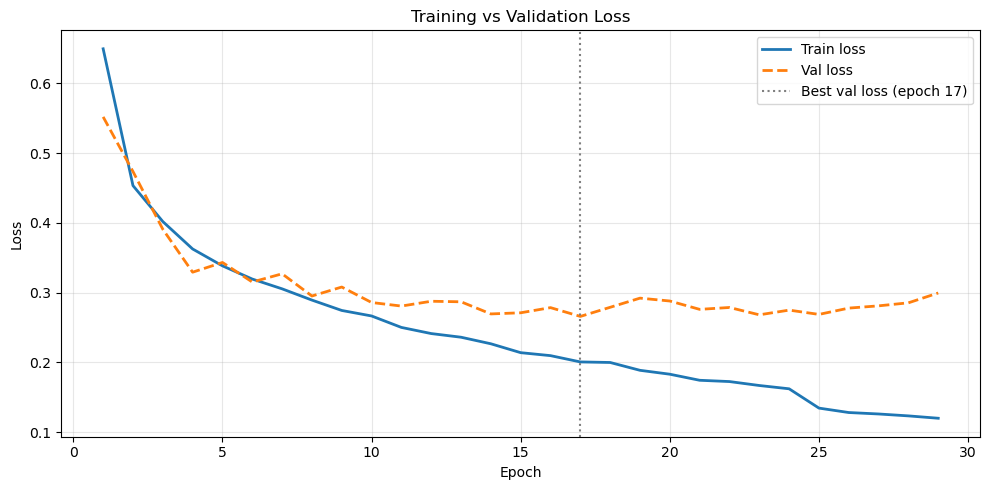

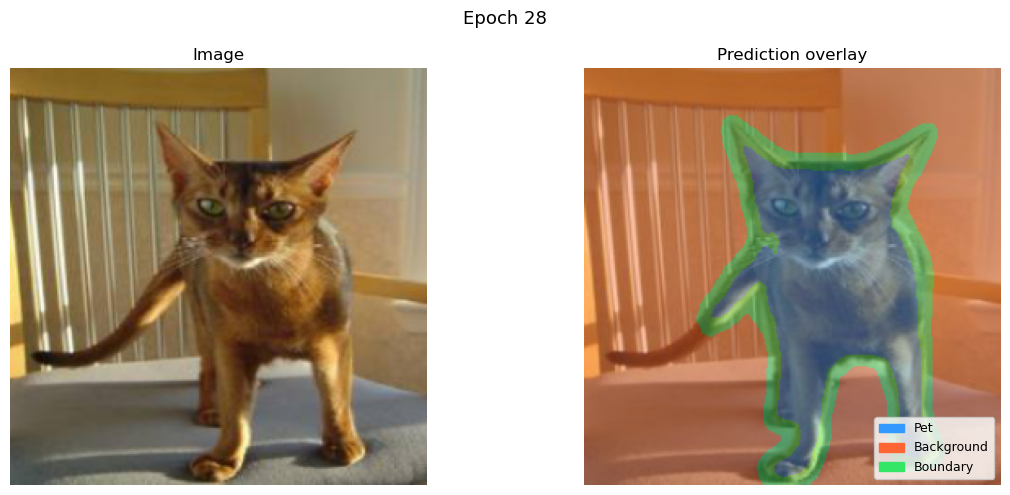

Epoch 29/40 train_loss: 0.1200 val_loss: 0.2995


KeyboardInterrupt: 

In [46]:
EPOCH = 40

train_losses = []
val_losses = []

for epoch in range(EPOCH):

    model.train()
    train_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        pred_mask = model(images)
        loss = criterion(pred_mask, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()


    model.eval()
    val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            pred_mask = model(images)
            loss = criterion(pred_mask, masks)

            val_loss += loss.item()
    
    scheduler.step(val_loss / len(val_loader))
    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))

    plot_losses(train_losses, val_losses)
    show_prediction(model, val_ds, device, epoch)
    
    print(f"Epoch {epoch+1}/{EPOCH} "
          f"train_loss: {train_loss/len(train_loader):.4f} "
          f"val_loss: {val_loss/len(val_loader):.4f}")

In [48]:
torch.mps.empty_cache()

In [47]:
torch.save(model.state_dict(), 'unet_pet.pth')
print("Model saved.")

Model saved.
